# EE519 — Notebook 3: emotion2vec Inference & Zero-Shot SER

## Overview
1. Install and load **emotion2vec+** models from FunASR
2. Run **zero-shot inference** on RAVDESS (no training on target dataset)
3. Compare **emotion2vec+ seed vs. base vs. large**
4. Evaluate against classical and Wav2Vec2 baselines
5. Visualize emotion embeddings

### References
- Ma et al. (2024). emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation. *ACL Findings*.
- emotion2vec GitHub: https://github.com/ddlBoJack/emotion2vec

In [ ]:
# Install dependencies
# !pip install funasr modelscope torch torchaudio librosa matplotlib seaborn scikit-learn tqdm

In [1]:
import os, glob, numpy as np, torch, librosa
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from collections import Counter
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')
print('Imports done')

Imports done


## 1. Load RAVDESS Data

In [ ]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name in ("notebooks_claude", "notebooks")
    else NOTEBOOK_DIR
)
RAVDESS_DIR = str(PROJECT_ROOT / "data" / "ravdess")
assert Path(RAVDESS_DIR).is_dir(), f"Missing {RAVDESS_DIR} — run scripts/download_kaggle_ravdess.py"
_wavs = list(Path(RAVDESS_DIR).glob("**/*.wav"))
assert _wavs, f"No WAV files under {RAVDESS_DIR}"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAVDESS_DIR:", RAVDESS_DIR, "| wav count:", len(_wavs))

EMOTION_MAP = {'01':'neutral','02':'calm','03':'happy','04':'sad','05':'angry','06':'fearful','07':'disgust','08':'surprised'}

def parse_ravdess(filepath):
    parts = os.path.basename(filepath).replace('.wav','').split('-')
    return {'filepath':filepath, 'emotion':EMOTION_MAP.get(parts[2],'unknown'),
            'actor_id':int(parts[6]), 'gender':'male' if int(parts[6])%2==1 else 'female'}

audio_files = sorted(glob.glob(os.path.join(RAVDESS_DIR,'**','*.wav'), recursive=True))
data = [parse_ravdess(f) for f in audio_files if os.path.basename(f).split('-')[0]=='03' and os.path.basename(f).split('-')[1]=='01']
print(f'Files: {len(data)}')
import os as _os
_cap = (_os.environ.get('SER_CLAUDE_MAX_SAMPLES') or '200').strip()
if data and _cap not in ('', '0') and len(data) > int(_cap):
    data = data[:int(_cap)]
    print(f'Subset for runtime: {len(data)} files')

## 2. Load emotion2vec+ Model

emotion2vec+ comes in three variants:
- **seed** (~90M): Fine-tuned with academic SER data from EmoBox
- **base** (~90M): Scaled with pseudo-labeled data
- **large** (~300M): Best performance, trained on 40k hours

All support **9-class emotions**:
```
0: angry, 1: disgusted, 2: fearful, 3: happy, 4: neutral,
5: other, 6: sad, 7: surprised, 8: unknown
```

In [ ]:
from funasr import AutoModel

# Choose model variant
# Options: 'iic/emotion2vec_plus_seed', 'iic/emotion2vec_plus_base', 'iic/emotion2vec_plus_large'
MODEL_ID = 'iic/emotion2vec_plus_base'

print(f'Loading {MODEL_ID}...')
e2v_model = AutoModel(model=MODEL_ID, hub='hf')  # Use 'ms' for ModelScope (China), 'hf' for HuggingFace
print('Model loaded!')

In [7]:
# emotion2vec label mapping
E2V_LABELS = {0:'angry', 1:'disgusted', 2:'fearful', 3:'happy', 4:'neutral',
              5:'other', 6:'sad', 7:'surprised', 8:'unknown'}

# Mapping from emotion2vec labels to RAVDESS labels
E2V_TO_RAVDESS = {
    'angry':'angry', 'disgusted':'disgust', 'fearful':'fearful',
    'happy':'happy', 'neutral':'neutral', 'sad':'sad',
    'surprised':'surprised', 'other':'calm', 'unknown':'calm'
}

def predict_emotion_e2v(filepath, model):
    """Run emotion2vec inference on a single file.
    Load with librosa (16 kHz mono) and pass a numpy waveform so FunASR does not use torchaudio.load (TorchCodec/ffmpeg)."""
    y, sr = librosa.load(filepath, sr=16000, mono=True)
    result = model.generate(y, granularity='utterance', extract_embedding=True)
    # result contains: feats, labels, scores
    scores = result[0]['scores']  # list of 9 scores
    pred_idx = np.argmax(scores)
    pred_label = E2V_LABELS[pred_idx]
    embedding = result[0]['feats']  # emotion embedding
    return pred_label, scores, embedding

# Test on one file
if data:
    pred, scores, emb = predict_emotion_e2v(data[0]['filepath'], e2v_model)
    print(f'Predicted: {pred}')
    print(f'Scores: {[f"{E2V_LABELS[i]}:{s:.3f}" for i,s in enumerate(scores)]}')
    print(f'Embedding shape: {np.array(emb).shape}')

rtf_avg: 0.118: 100%|██████████| 1/1 [00:00<00:00,  2.55it/s]                                                                                      

Predicted: neutral
Scores: ['angry:0.000', 'disgusted:0.000', 'fearful:0.000', 'happy:0.000', 'neutral:1.000', 'other:0.000', 'sad:0.000', 'surprised:0.000', 'unknown:0.000']
Embedding shape: (768,)


## 3. Zero-Shot Evaluation on RAVDESS

This is **zero-shot** — emotion2vec was NOT trained on RAVDESS. We directly use its predictions.

**Subject-independent reporting:** we report **overall** UAR/accuracy and **per-speaker** UAR (balanced accuracy computed within each `actor_id`, then mean ± std across speakers). The latter summarizes how consistently the model generalizes across different subjects.

In [8]:
# Run inference on all files
predictions, true_labels, embeddings, all_scores, actor_ids = [], [], [], [], []
print('Running emotion2vec inference...')
for d in tqdm(data):
    try:
        pred_label, scores, emb = predict_emotion_e2v(d['filepath'], e2v_model)
        mapped_pred = E2V_TO_RAVDESS.get(pred_label, 'neutral')
        predictions.append(mapped_pred)
        true_labels.append(d['emotion'])
        actor_ids.append(d['actor_id'])
        embeddings.append(np.array(emb).flatten())
        all_scores.append(scores)
    except Exception as e:
        print(f'Error: {e}')

predictions = np.array(predictions); true_labels = np.array(true_labels)
actor_ids = np.asarray(actor_ids, dtype=np.int64)
embeddings = np.array(embeddings)
print(f'Processed: {len(predictions)} files')

Running emotion2vec inference...


100%|██████████| 200/200 [00:59<00:00,  3.37it/s]

Processed: 200 files


In [9]:
# Evaluate
le = LabelEncoder()
le.fit(np.unique(np.concatenate([true_labels, predictions])))
y_true_enc = le.transform(true_labels)
y_pred_enc = le.transform(predictions)
class_names = le.classes_

uar = balanced_accuracy_score(y_true_enc, y_pred_enc)
acc = accuracy_score(y_true_enc, y_pred_enc)

print(f'emotion2vec+ ({MODEL_ID.split("/")[-1]})')
print(f'Zero-Shot UAR (overall): {uar:.3f}, Accuracy: {acc:.3f}')
per_spk = [balanced_accuracy_score(y_true_enc[actor_ids == aid], y_pred_enc[actor_ids == aid])
           for aid in np.unique(actor_ids) if np.sum(actor_ids == aid) > 0]
if per_spk:
    print(f'Per-speaker UAR (mean ± std over {len(per_spk)} actors): {np.mean(per_spk):.3f} ± {np.std(per_spk):.3f}')
print(classification_report(y_true_enc, y_pred_enc, target_names=class_names, digits=3))

emotion2vec+ (emotion2vec_plus_base)
Zero-Shot UAR (overall): 0.861, Accuracy: 0.825
Per-speaker UAR (mean ± std over 4 actors): 0.805 ± 0.105
              precision    recall  f1-score   support

       angry      0.960     1.000     0.980        24
        calm      0.000     0.000     0.000        32
     disgust      0.960     1.000     0.980        24
     fearful      1.000     0.917     0.957        24
       happy      1.000     0.969     0.984        32
     neutral      0.400     1.000     0.571        16
         sad      0.727     1.000     0.842        24
   surprised      1.000     1.000     1.000        24

    accuracy                          0.825       200
   macro avg      0.756     0.861     0.789       200
weighted avg      0.750     0.825     0.774       200



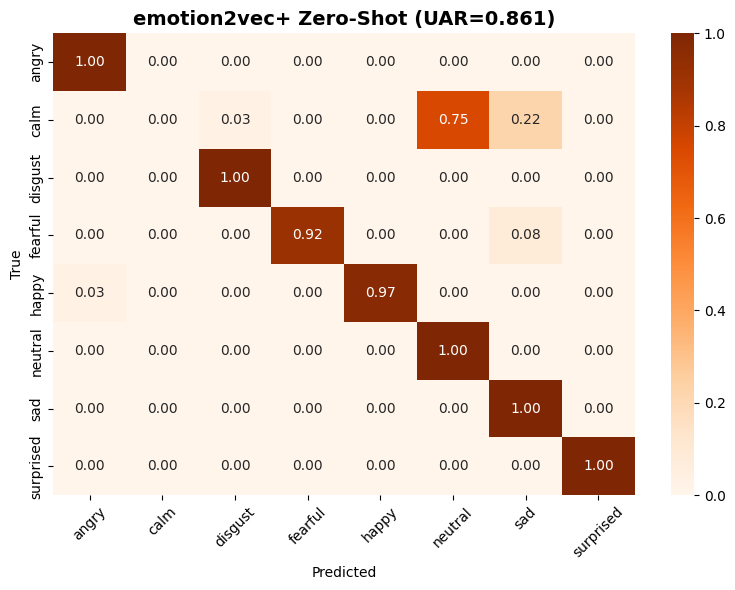

In [10]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true_enc, y_pred_enc, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'emotion2vec+ Zero-Shot (UAR={uar:.3f})', fontsize=14, fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 4. Embedding Visualization

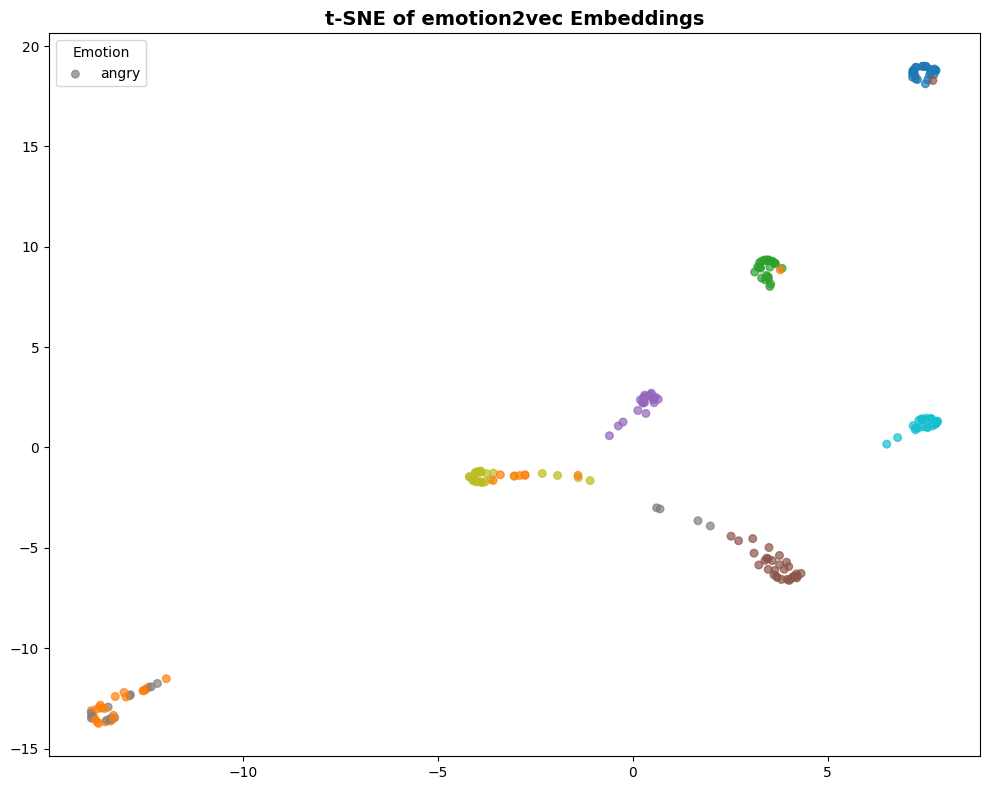

In [11]:
# t-SNE of emotion2vec embeddings
if len(embeddings) > 0 and embeddings[0].shape[0] > 2:
    le2 = LabelEncoder(); y_enc2 = le2.fit_transform(true_labels)
    X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
        StandardScaler().fit_transform(embeddings))
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_enc2, cmap='tab10', alpha=0.7, s=30)
    plt.legend(*scatter.legend_elements(), title='Emotion', labels=list(le2.classes_))
    plt.title('t-SNE of emotion2vec Embeddings', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Embedding extraction not available in this model variant.')

## 5. Score Distribution Analysis

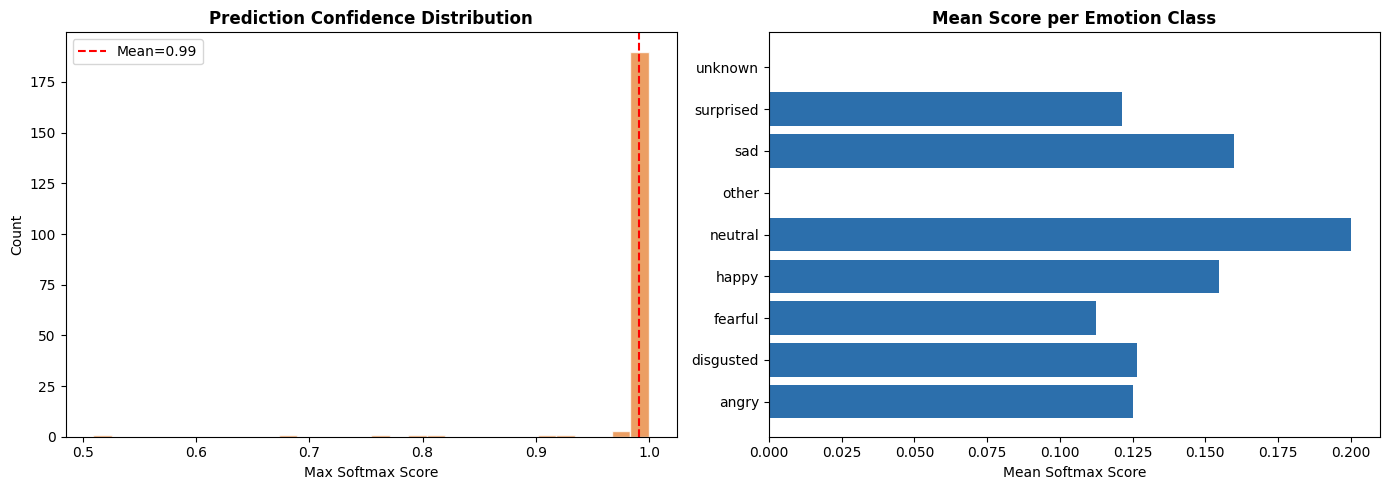

In [12]:
# Analyze confidence distributions
all_scores_arr = np.array(all_scores)
max_scores = np.max(all_scores_arr, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence histogram
axes[0].hist(max_scores, bins=30, color='#E8873D', edgecolor='white', alpha=0.8)
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Max Softmax Score'); axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(max_scores), color='red', linestyle='--', label=f'Mean={np.mean(max_scores):.2f}')
axes[0].legend()

# Per-class mean scores
e2v_label_names = [E2V_LABELS[i] for i in range(9)]
mean_scores = np.mean(all_scores_arr, axis=0)
axes[1].barh(e2v_label_names, mean_scores, color='#2C6FAC')
axes[1].set_title('Mean Score per Emotion Class', fontweight='bold')
axes[1].set_xlabel('Mean Softmax Score')

plt.tight_layout(); plt.show()

## Summary

| Method | Type | UAR on RAVDESS |
|:---|:---|:---|
| Classical + SVM | Supervised | See Notebook 1 |
| Wav2Vec2 + SVM | Linear Probe | See Notebook 2 |
| emotion2vec+ | **Zero-Shot** | See above |

**Key takeaways:**
- emotion2vec achieves strong zero-shot performance without any training on RAVDESS
- The model captures universal emotion representations across languages and datasets
- Confusion patterns differ from supervised models (different biases)

**Next: Notebook 4** — Multimodal extension (audio + text fusion)